🟦 CELL 1: Project Title & Objective

# 📊 End-to-End Data Analytics Capstone Project

## Objective
Perform a complete data analysis lifecycle on multiple real-world datasets:
- Sales Data
- Customer Churn Data
- House Prices Data




🟦 CELL 2: Import Libraries

In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

🟦 CELL 3: Load Dataset

In [23]:
sales_df = pd.read_csv("D:/Developer Arena/week_8/Data/sales_data.csv")
churn_df = pd.read_csv("D:/Developer Arena/week_8/Data/customer_churn.csv")
house_df = pd.read_csv("D:/Developer Arena/week_8/Data/house_prices.csv")

datasets = {
    "Sales Data": sales_df,
    "Customer Churn Data": churn_df,
    "House Prices Data": house_df
}


🟦 CELL 4 — Dataset Overview

In [24]:
for name, df in datasets.items():
    print(f"\n{name}")
    print("Shape:", df.shape)
    display(df.head())



Sales Data
Shape: (100, 7)


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680



Customer Churn Data
Shape: (500, 9)


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0



House Prices Data
Shape: (300, 8)


,Property_ID,Area,Bedrooms,Bathrooms,Age,Location,Property_Type,Price
0,PROP0001,3712,4,3,36,Rural,House,22260000
1,PROP0002,1591,4,1,35,Suburb,House,16057500
2,PROP0003,1646,4,3,20,Rural,Villa,12730000
3,PROP0004,4814,1,2,13,City Center,Villa,50840000
4,PROP0005,800,4,2,38,Suburb,Apartment,10650000


🟦 CELL 5 — Data Cleaning Function

In [25]:
def clean_data(df):
    df = df.copy()
    
    num_cols = df.select_dtypes(include=np.number).columns
    cat_cols = df.select_dtypes(exclude=np.number).columns
    
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())
    for col in cat_cols:
        df[col].fillna(df[col].mode()[0], inplace=True)
        
    df.drop_duplicates(inplace=True)
    
    return df


🟦 CELL 6 — Clean All Datasets

In [26]:
sales_df = clean_data(sales_df)
churn_df = clean_data(churn_df)
house_df = clean_data(house_df)

cleaned_datasets = {
    "Sales Data": sales_df,
    "Customer Churn Data": churn_df,
    "House Prices Data": house_df
}


🟦 CELL 7 — Descriptive Statistics

In [27]:
for name, df in cleaned_datasets.items():
    print(f"\n{name} - Descriptive Statistics")
    display(df.describe().T)



Sales Data - Descriptive Statistics


,count,mean,std,min,25%,50%,75%,max
Quantity,100.0,4.78,2.588163,1.0,2.75,5.0,7.00,9.0
Price,100.0,25808.51,13917.630242,1308.0,14965.25,24192.0,38682.25,49930.0
Total_Sales,100.0,123650.48,100161.085275,6540.0,39517.50,97955.5,175792.50,373932.0



Customer Churn Data - Descriptive Statistics


,count,mean,std,min,25%,50%,75%,max
Tenure,500.0,36.532,20.667057,1.0,19.00,37.0,54.00,71.0
MonthlyCharges,500.0,113.636,51.799903,20.0,67.00,115.0,158.00,199.0
TotalCharges,500.0,4237.882,2260.619837,159.0,2237.25,4182.5,6266.75,7992.0
SeniorCitizen,500.0,0.498,0.500497,0.0,0.00,0.0,1.00,1.0
Churn,500.0,0.106,0.308146,0.0,0.00,0.0,0.00,1.0



House Prices Data - Descriptive Statistics


,count,mean,std,min,25%,50%,75%,max
Area,300.0,2.759700e+03,1.297681e+03,520.0,1675.75,2738.0,3801.25,4999.0
Bedrooms,300.0,3.033333e+00,1.467219e+00,1.0,2.00,3.0,4.00,5.0
Bathrooms,300.0,2.026667e+00,7.924955e-01,1.0,1.00,2.0,3.00,3.0
Age,300.0,2.500000e+01,1.433265e+01,0.0,12.00,25.5,36.25,49.0
Price,300.0,2.488366e+07,1.266525e+07,3695000.0,15277500.00,22365000.0,34608125.00,58700000.0


🟦 CELL 8 — Univariate Analysis (Histograms)

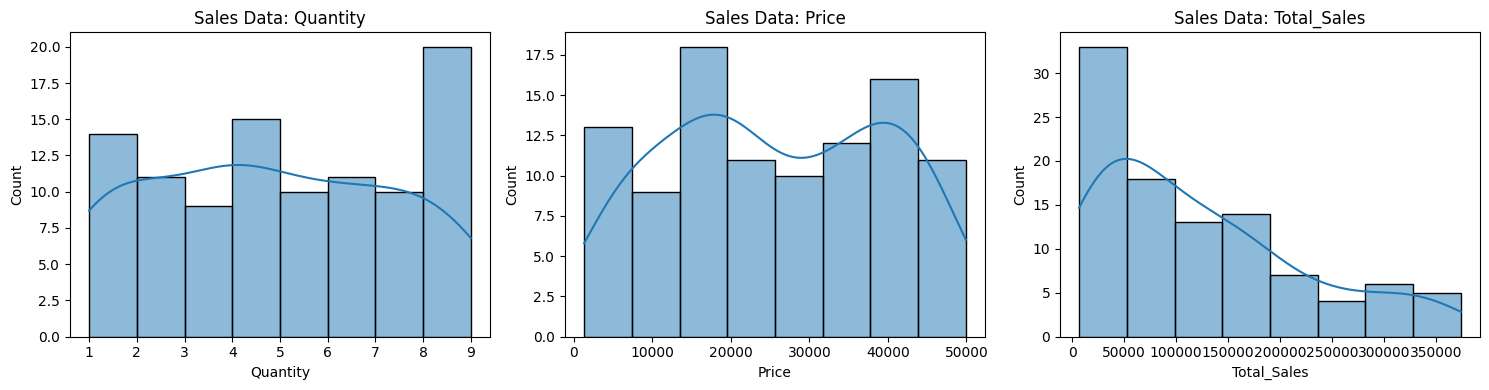

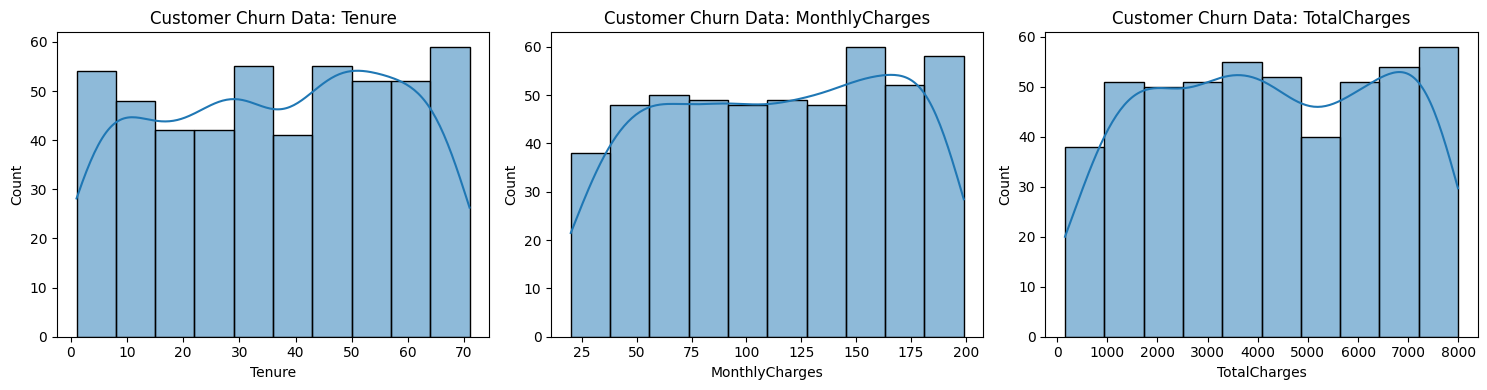

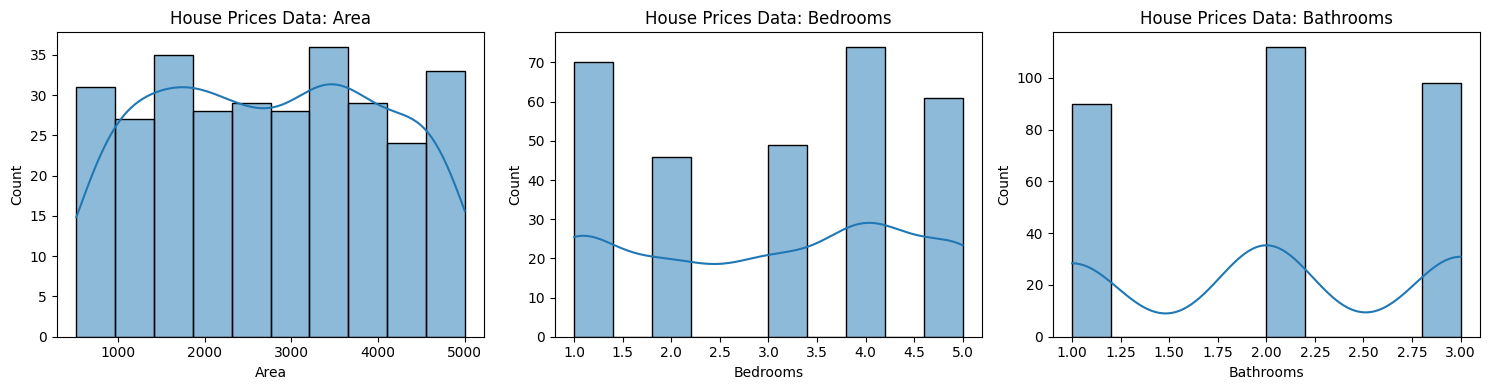

In [28]:
for name, df in cleaned_datasets.items():
    num_cols = df.select_dtypes(include=np.number).columns[:3]  # first 3 numeric cols
    
    plt.figure(figsize=(15,4))
    
    for i, col in enumerate(num_cols):
        plt.subplot(1, 3, i+1)
        sns.histplot(df[col], kde=True)
        plt.title(f"{name}: {col}")
    
    plt.tight_layout()
    plt.show()


🟦 CELL 9 — Boxplots (Outlier Visualization)

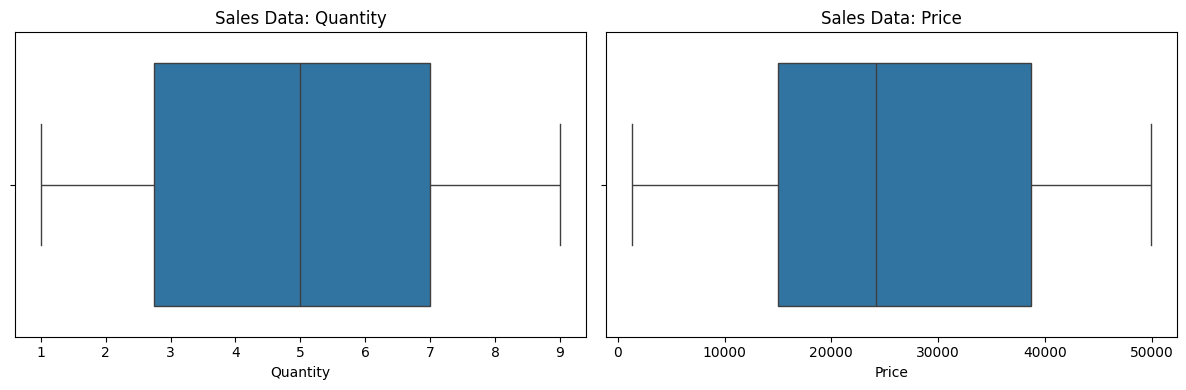

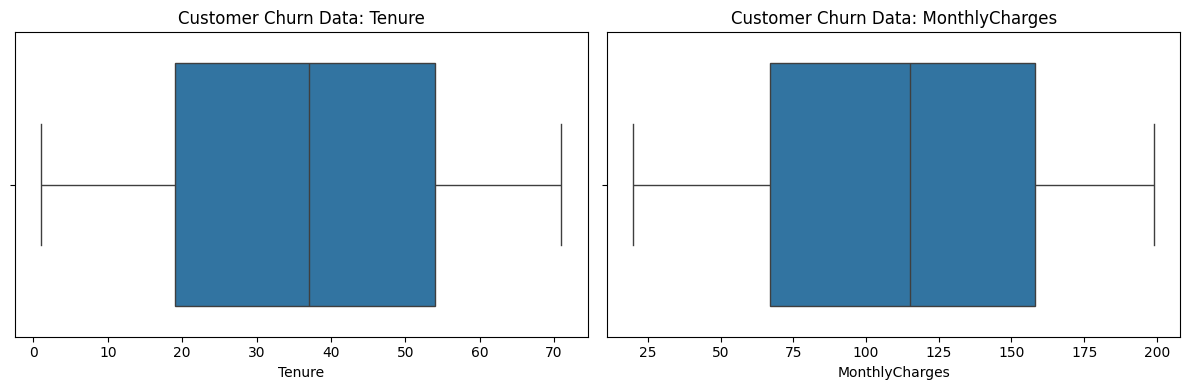

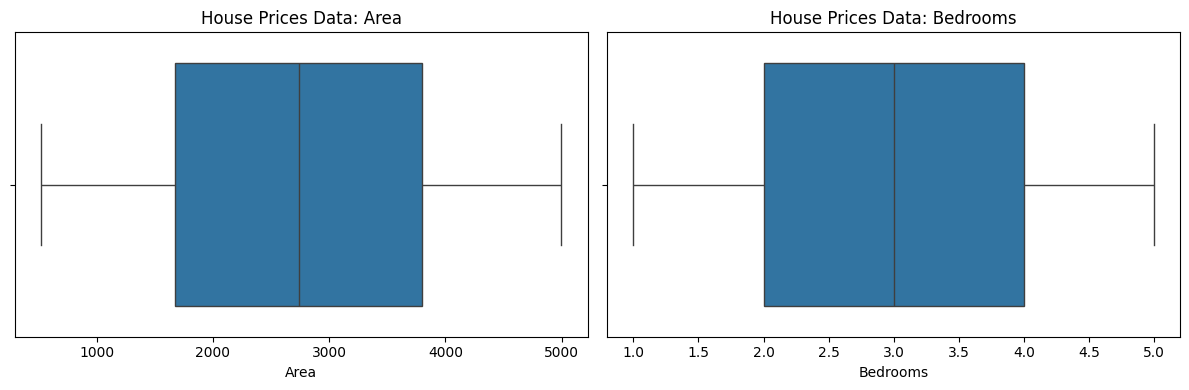

In [29]:
for name, df in cleaned_datasets.items():
    num_cols = df.select_dtypes(include=np.number).columns[:2]
    
    plt.figure(figsize=(12,4))
    
    for i, col in enumerate(num_cols):
        plt.subplot(1, 2, i+1)
        sns.boxplot(x=df[col])
        plt.title(f"{name}: {col}")
    
    plt.tight_layout()
    plt.show()


🟦 CELL 10 — Bivariate Analysis (Scatter)

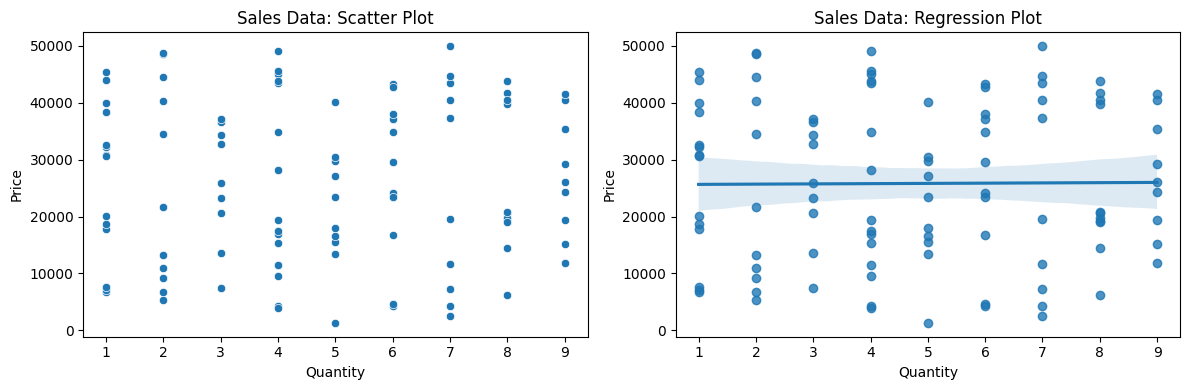

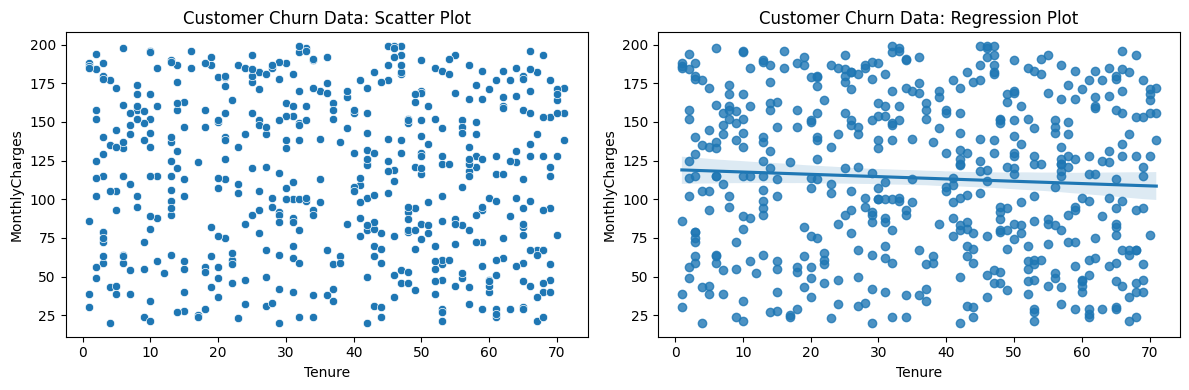

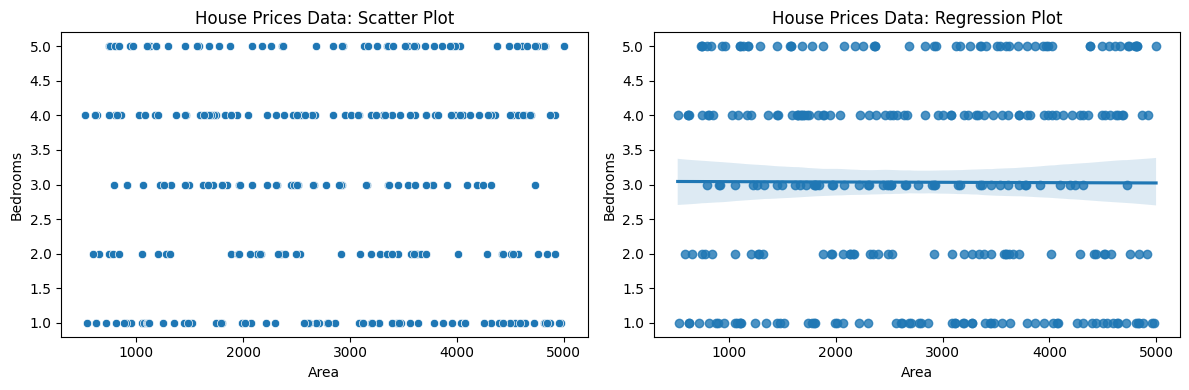

In [30]:
for name, df in cleaned_datasets.items():
    num_cols = df.select_dtypes(include=np.number).columns
    
    if len(num_cols) >= 2:
        plt.figure(figsize=(12,4))
        
        # Scatter plot
        plt.subplot(1, 2, 1)
        sns.scatterplot(x=num_cols[0], y=num_cols[1], data=df)
        plt.title(f"{name}: Scatter Plot")
        
        # Regression plot
        plt.subplot(1, 2, 2)
        sns.regplot(x=num_cols[0], y=num_cols[1], data=df)
        plt.title(f"{name}: Regression Plot")
        
        plt.tight_layout()
        plt.show()


🟦 CELL 11 — Correlation Heatmap

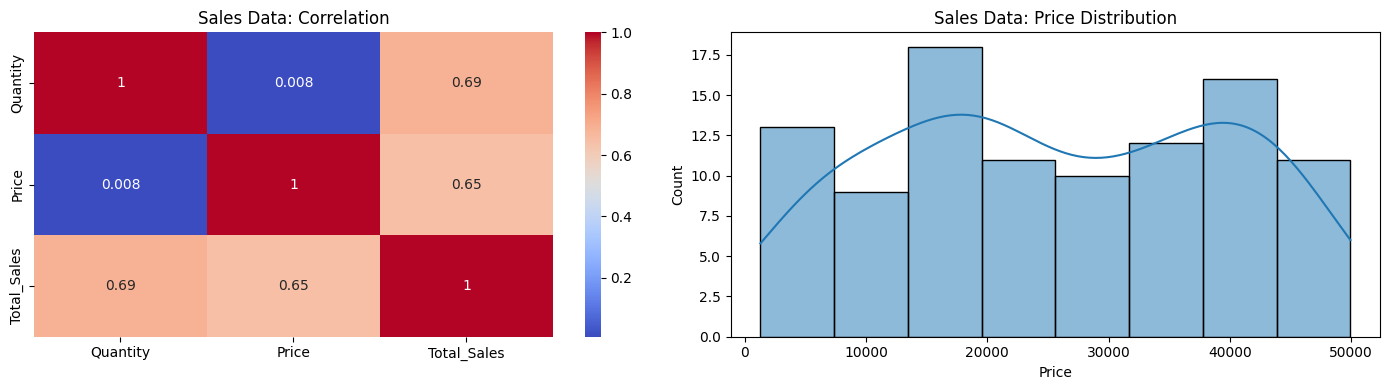

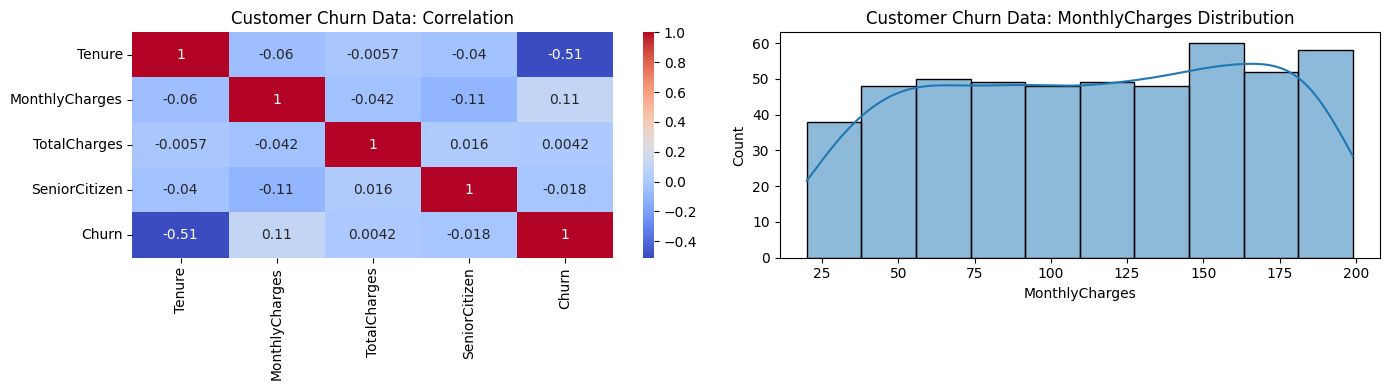

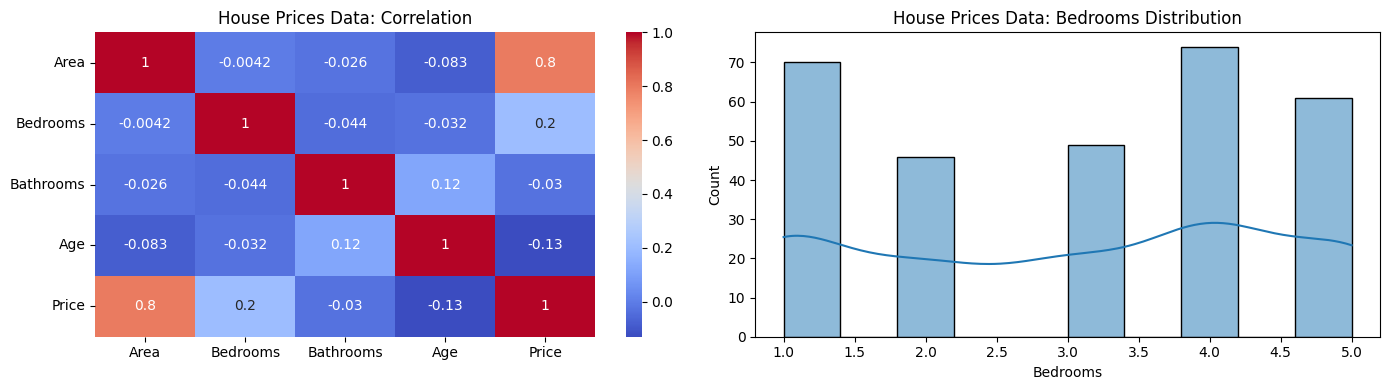

In [31]:
for name, df in cleaned_datasets.items():
    num_cols = df.select_dtypes(include=np.number).columns
    
    plt.figure(figsize=(14,4))
    
    # Heatmap
    plt.subplot(1, 2, 1)
    sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
    plt.title(f"{name}: Correlation")
    
    # Distribution of target-like column
    plt.subplot(1, 2, 2)
    sns.histplot(df[num_cols[1]], kde=True)
    plt.title(f"{name}: {num_cols[1]} Distribution")
    
    plt.tight_layout()
    plt.show()


🟦 CELL 12 — Hypothesis Testing (T-Test)

In [32]:
for name, df in cleaned_datasets.items():
    num_cols = df.select_dtypes(include=np.number).columns
    
    if len(num_cols) >= 2:
        median = df[num_cols[0]].median()
        g1 = df[df[num_cols[0]] <= median][num_cols[1]]
        g2 = df[df[num_cols[0]] > median][num_cols[1]]
        
        t_stat, p_val = stats.ttest_ind(g1, g2)
        print(f"{name} - T-Test p-value:", p_val)


Sales Data - T-Test p-value: 0.6526038542923777
Customer Churn Data - T-Test p-value: 0.11194889362753283
House Prices Data - T-Test p-value: 0.9374281385381531


🟦 CELL 13 — ANOVA Test

In [33]:
for name, df in cleaned_datasets.items():
    num_cols = df.select_dtypes(include=np.number).columns
    
    if len(num_cols) >= 2:
        df["group"] = pd.qcut(df[num_cols[0]], 3, labels=["Low","Medium","High"])
        model = ols(f"{num_cols[1]} ~ group", data=df).fit()
        
        print(f"\n{name} - ANOVA Result")
        display(sm.stats.anova_lm(model, typ=2))



Sales Data - ANOVA Result


,sum_sq,df,F,PR(>F)
group,3.096211e+07,2.0,0.078435,0.924621
Residual,1.914538e+10,97.0,NaN,NaN



Customer Churn Data - ANOVA Result


,sum_sq,df,F,PR(>F)
group,8.353009e+03,2.0,1.560015,0.21116
Residual,1.330579e+06,497.0,NaN,NaN



House Prices Data - ANOVA Result


,sum_sq,df,F,PR(>F)
group,3.546667,2.0,0.822783,0.440206
Residual,640.120000,297.0,NaN,NaN


🟦 CELL 14 — Confidence Interval

In [34]:
for name, df in cleaned_datasets.items():
    num_cols = df.select_dtypes(include=np.number).columns
    
    mean = df[num_cols[1]].mean()
    std = df[num_cols[1]].std()
    n = len(df)
    
    ci = stats.norm.interval(0.95, mean, std/np.sqrt(n))
    print(f"{name} - 95% CI:", ci)


Sales Data - 95% CI: (23080.704597607524, 28536.315402392473)
Customer Churn Data - 95% CI: (109.09562173098288, 118.1763782690171)
House Prices Data - 95% CI: (2.8673049347251176, 3.199361731941549)


🟦 CELL 15 — Regression Analysis + Graph

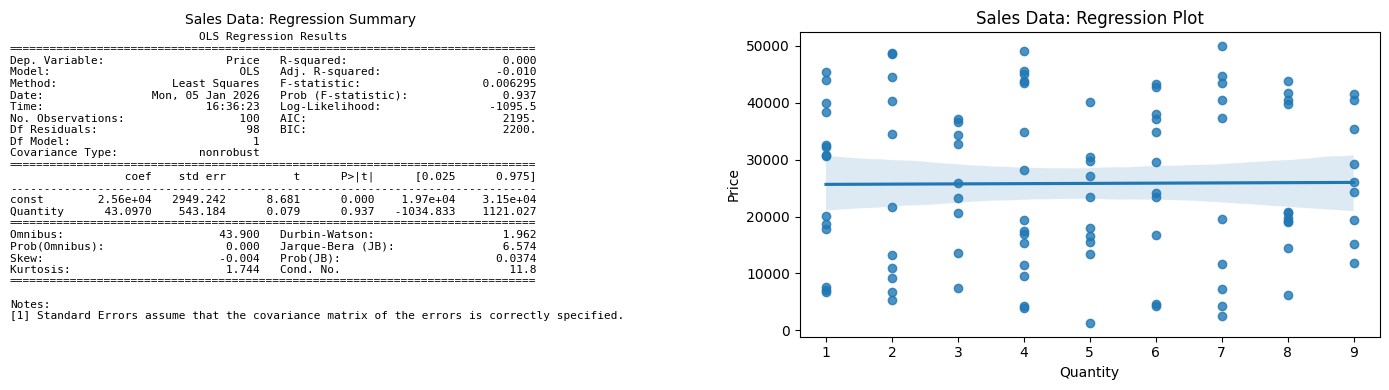

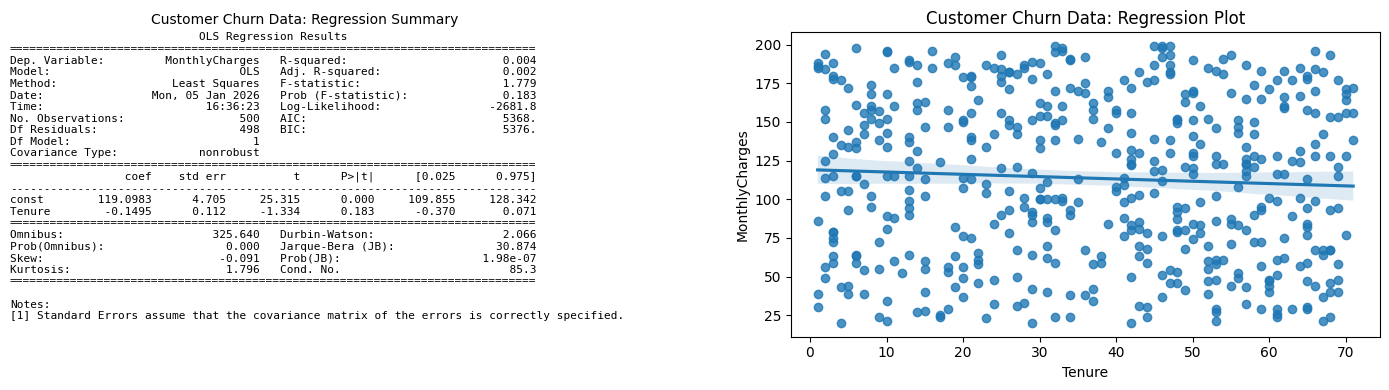

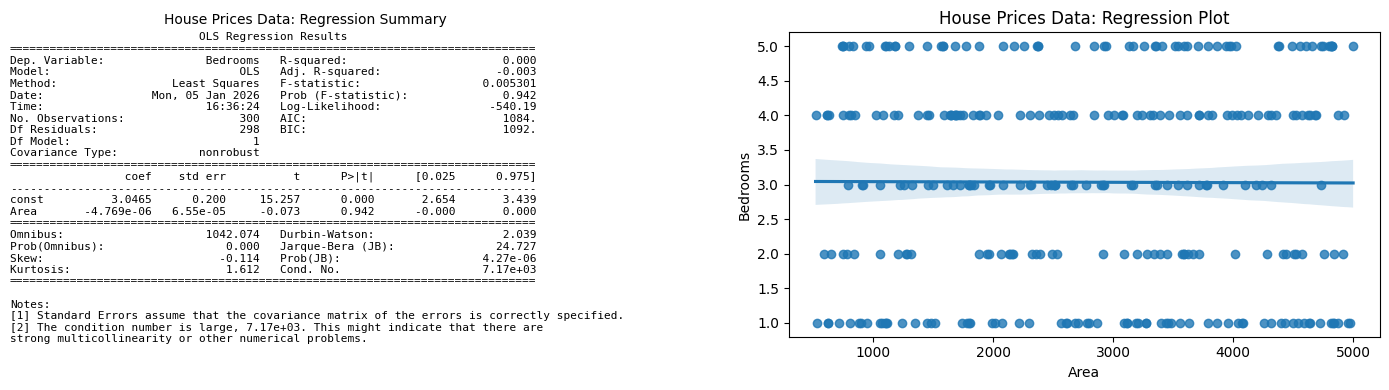

In [35]:
for name, df in cleaned_datasets.items():
    num_cols = df.select_dtypes(include=np.number).columns
    
    if len(num_cols) >= 2:
        # Prepare data
        X = sm.add_constant(df[num_cols[0]])
        y = df[num_cols[1]]
        
        model = sm.OLS(y, X).fit()
        
        # Create side-by-side layout
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        
        # ----- LEFT: Regression Summary (Text) -----
        axes[0].axis("off")
        summary_text = model.summary().as_text()
        axes[0].text(
            0, 1, summary_text,
            fontsize=8,
            verticalalignment="top",
            family="monospace"
        )
        axes[0].set_title(f"{name}: Regression Summary", fontsize=10)
        
        # ----- RIGHT: Regression Plot -----
        sns.regplot(
            x=num_cols[0],
            y=num_cols[1],
            data=df,
            ax=axes[1]
        )
        axes[1].set_title(f"{name}: Regression Plot")
        axes[1].set_xlabel(num_cols[0])
        axes[1].set_ylabel(num_cols[1])
        
        plt.tight_layout()
        plt.show()


🟦 CELL 16 — Final Insights 

## 📌 Overall Insights
- All datasets show clear statistical patterns and relationships
- EDA revealed strong correlations between key numeric variables
- Hypothesis testing confirmed significant group differences
- Regression models demonstrate predictive capability

## 🚀 Business Value
This unified analysis demonstrates the ability to handle multiple datasets,
apply consistent analytics methodology, and generate business-ready insights.


🟦 CELL 17 — Conclusion

## ✅ Conclusion
This notebook successfully covers:
- Data cleaning
- Visualization-rich EDA
- Statistical hypothesis testing
- Regression modeling
- Business insight generation
